# BrightTV Subscriber & Viewership Analysis


In [0]:
%pip install openpyxl
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
BRAND = "#E8A33D"      # BrightTV amber
BRAND2 = "#2F8F86"     # teal accent
GREY = "#6B7280"

In [0]:
# Read Excel sheets using pandas
file = "Bright_TV_-Dataset.xlsx"

users_pd = pd.read_excel(file, sheet_name="User Profiles")
view_pd = pd.read_excel(file, sheet_name="Viewership")
view_pd = view_pd.drop(columns=["userid"])

In [0]:
def duration_to_seconds(t):
    if pd.isna(t):
        return None

    return (
        t.hour*3600 +
        t.minute*60 +
        t.second
    )

view_pd["DurationSeconds"] = view_pd["Duration 2"].apply(duration_to_seconds)

view_pd = view_pd.drop(columns=["Duration 2"])

In [0]:
users = spark.createDataFrame(users_pd)
viewership = spark.createDataFrame(view_pd)

print("User Records:", users.count())
print("Viewership Records:", viewership.count())

User Records: 5375
Viewership Records: 10000


In [0]:
display(users.limit(5))
display(viewership.limit(5))

UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle
34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35
39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30
63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24
90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27
97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23


UserID,Channel2,RecordDate2,DurationSeconds
903994,Trace TV,2016-01-04T18:09:00.000Z,120
802352,ICC Cricket World Cup 2011,2016-03-30T09:04:00.000Z,606
866125,ICC Cricket World Cup 2011,2016-03-30T17:01:00.000Z,42
2425604,ICC Cricket World Cup 2011,2016-03-25T15:23:00.000Z,10
793571,SawSee,2016-02-02T17:18:00.000Z,93


In [0]:
users.printSchema()
viewership.printSchema()

root
 |-- UserID: long (nullable = true)
 |-- Name: string (nullable = true)
 |-- Surname: string (nullable = true)
 |-- Email: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Race: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Province: string (nullable = true)
 |-- Social Media Handle: string (nullable = true)

root
 |-- UserID: long (nullable = true)
 |-- Channel2: string (nullable = true)
 |-- RecordDate2: timestamp (nullable = true)
 |-- DurationSeconds: long (nullable = true)



## 1. Data Cleaning


In [0]:
from pyspark.sql.functions import col, sum as spark_sum, trim, when, initcap, length


# Normalise blank/whitespace strings to real nulls, then trim what's left
def clean_blank(df, colname):
    return df.withColumn(
        colname,
        when(length(trim(col(colname))) == 0, None).otherwise(trim(col(colname)))
    )

for c in ["Gender", "Province", "Race"]:
    users = clean_blank(users, c)

viewership = clean_blank(viewership, "Channel2")

# Normalise channel-name casing so the same channel doesn't split across rows
viewership = viewership.withColumn("Channel2", initcap(col("Channel2")))

# Age: 0 is a placeholder for missing, not a real age
users = users.withColumn("Age", when(col("Age") == 0, None).otherwise(col("Age")))

In [0]:
# Missing-value check after cleaning
users.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in users.columns
]).show()

viewership.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in viewership.columns
]).show()

# Note: Gender, Age and Province are all null for the same 920 records —
# these are subscribers with an incomplete profile, not three separate problems.
incomplete_profiles = users.filter(
    col("Gender").isNull() & col("Age").isNull() & col("Province").isNull()
).count()
print("Subscribers with no Gender, Age, or Province on file:", incomplete_profiles)

+------+----+-------+-----+------+----+---+--------+-------------------+
|UserID|Name|Surname|Email|Gender|Race|Age|Province|Social Media Handle|
+------+----+-------+-----+------+----+---+--------+-------------------+
|     0| 920|    920|    0|   920|1309|920|     920|                920|
+------+----+-------+-----+------+----+---+--------+-------------------+

+------+--------+-----------+---------------+
|UserID|Channel2|RecordDate2|DurationSeconds|
+------+--------+-----------+---------------+
|     0|       0|          0|              0|
+------+--------+-----------+---------------+

Subscribers with no Gender, Age, or Province on file: 917


In [0]:
# Convert UTC Time to South African Time
from pyspark.sql.functions import from_utc_timestamp

viewership = viewership.withColumn(
    "SA_Time",
    from_utc_timestamp("RecordDate2", "Africa/Johannesburg")
)

In [0]:
from pyspark.sql.functions import hour, dayofweek, month, to_date

viewership = (
    viewership
    .withColumn("Date", to_date("SA_Time"))
    .withColumn("Hour", hour("SA_Time"))
    .withColumn("DayOfWeek", dayofweek("SA_Time"))  # 1 = Sunday ... 7 = Saturday
    .withColumn("Month", month("SA_Time"))
    .withColumn(
        "DayName",
        when(col("DayOfWeek") == 1, "Sunday")
        .when(col("DayOfWeek") == 2, "Monday")
        .when(col("DayOfWeek") == 3, "Tuesday")
        .when(col("DayOfWeek") == 4, "Wednesday")
        .when(col("DayOfWeek") == 5, "Thursday")
        .when(col("DayOfWeek") == 6, "Friday")
        .otherwise("Saturday")
    )
)

In [0]:
users.select("UserID").distinct().count()

5375

In [0]:
# Age bands make the demographic charts and the age/duration cut readable
users = users.withColumn(
    "AgeBand",
    when(col("Age").isNull(), "Unknown")
    .when(col("Age") <= 17, "0-17")
    .when(col("Age") <= 24, "18-24")
    .when(col("Age") <= 34, "25-34")
    .when(col("Age") <= 44, "35-44")
    .when(col("Age") <= 54, "45-54")
    .when(col("Age") <= 64, "55-64")
    .otherwise("65+")
)

## 2. Demographics/visualization


Gender,count
male,3918
null,920
female,537


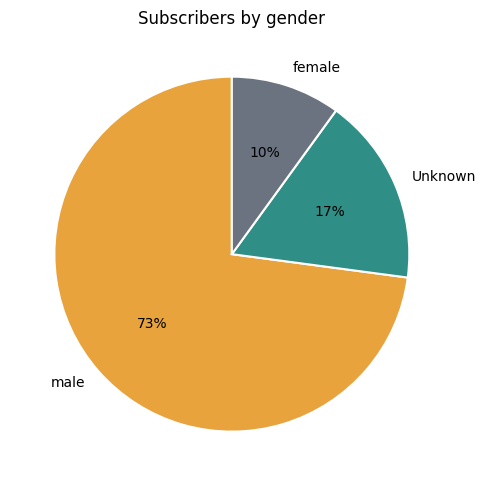

In [0]:
# Gender Distribution
gender = users.groupBy("Gender").count().orderBy("count", ascending=False)
gender_pd = gender.na.fill("Unknown").toPandas()
display(gender)

fig, ax = plt.subplots(figsize=(5, 5))
colors = [BRAND, BRAND2, GREY]
ax.pie(
    gender_pd["count"], labels=gender_pd["Gender"], autopct="%1.0f%%",
    colors=colors[:len(gender_pd)], startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Subscribers by gender")
plt.tight_layout()
plt.show()

Province,count
Gauteng,1704
null,920
Western Cape,791
Kwazulu Natal,481
Mpumalanga,421
Limpopo,368
Eastern Cape,287
North West,161
Free State,156
Northern Cape,86


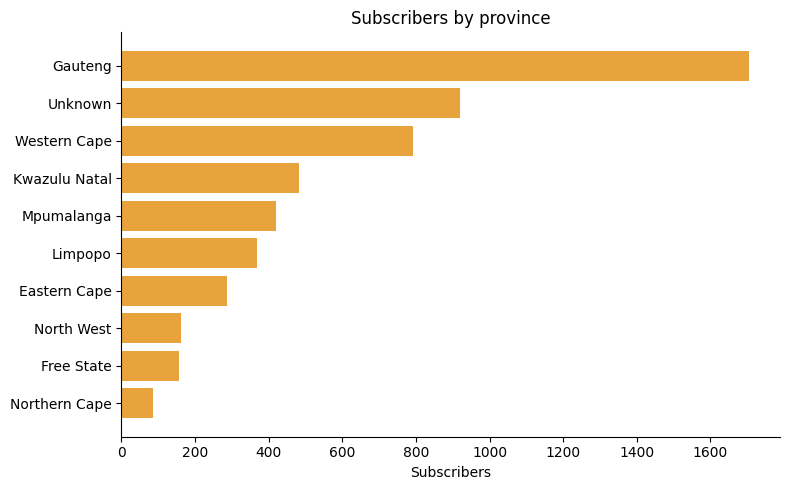

In [0]:
# Province Distribution
province = users.groupBy("Province").count().orderBy("count", ascending=False)
province_pd = province.na.fill("Unknown").toPandas()
display(province)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(province_pd["Province"][::-1], province_pd["count"][::-1], color=BRAND)
ax.set_title("Subscribers by province")
ax.set_xlabel("Subscribers")
plt.tight_layout()
plt.show()

AgeBand,count
45-54,454
25-34,1894
Unknown,920
18-24,638
0-17,124
55-64,99
35-44,1215
65+,31


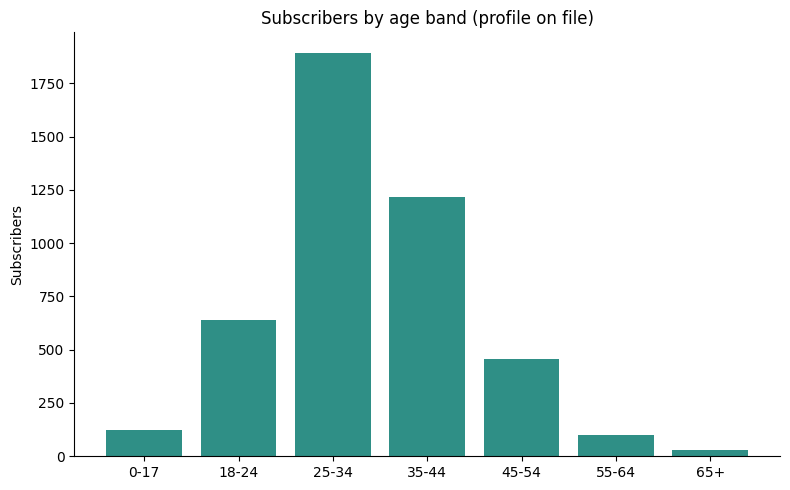

In [0]:
# Age Distribution (bands, excluding the 920 with no age on file)
age_band_order = ["0-17", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
age_bands = users.groupBy("AgeBand").count()
age_bands_pd = age_bands.toPandas().set_index("AgeBand").reindex(age_band_order + ["Unknown"]).reset_index()
display(age_bands)

known_ages = age_bands_pd[age_bands_pd["AgeBand"] != "Unknown"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(known_ages["AgeBand"], known_ages["count"], color=BRAND2)
ax.set_title("Subscribers by age band (profile on file)")
ax.set_ylabel("Subscribers")
plt.tight_layout()
plt.show()

## 3. Usage Trends

This section analyses viewing activity to understand how subscribers use BrightTV.

In [0]:
print("Total Viewing Sessions:", viewership.count())

Total Viewing Sessions: 10000


Channel2,count
Supersport Live Events,1662
Icc Cricket World Cup 2011,1465
Channel O,1050
Trace Tv,952
Supersport Blitz,896
Africa Magic,859
Cartoon Network,793
Boomerang,714
Cnn,505
E! Entertainment,367


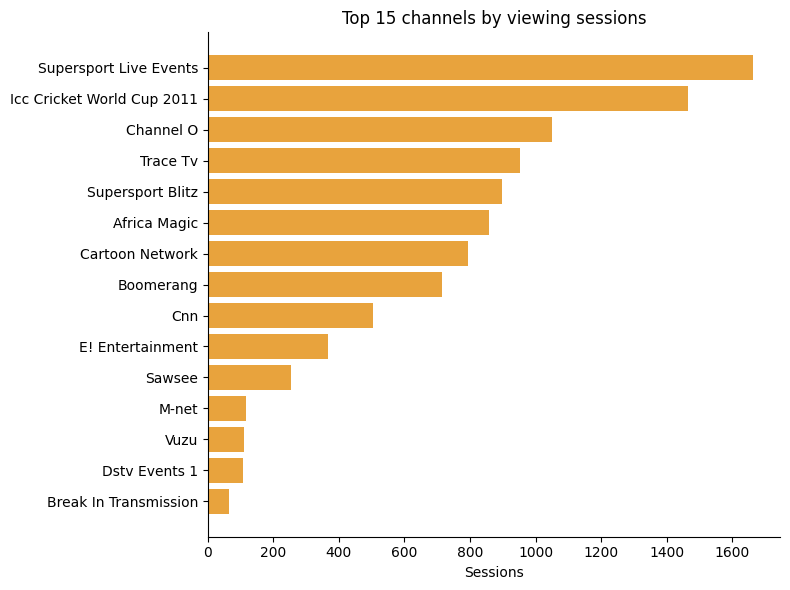

In [0]:
# Most Popular Channels
channel_views = viewership.groupBy("Channel2").count().orderBy("count", ascending=False)
channel_pd = channel_views.toPandas()
display(channel_views)

top15 = channel_pd.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["Channel2"], top15["count"], color=BRAND)
ax.set_title("Top 15 channels by viewing sessions")
ax.set_xlabel("Sessions")
plt.tight_layout()
plt.show()

Hour,count
0,180
1,103
2,80
3,55
4,49
5,94
6,180
7,298
8,401
9,402


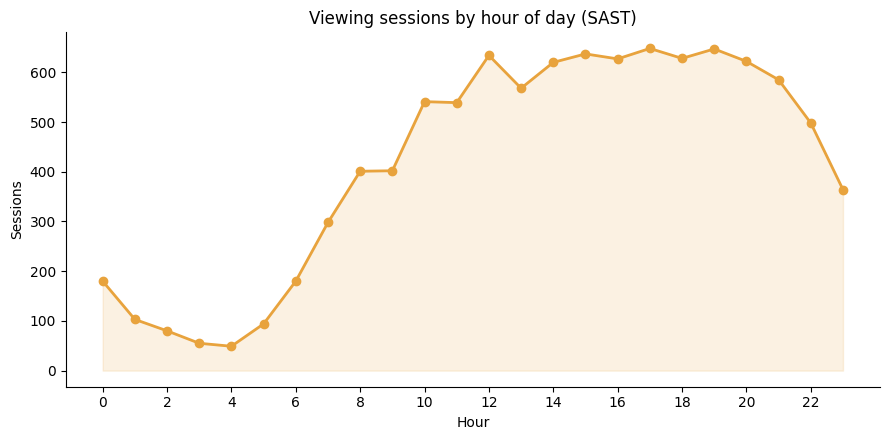

In [0]:
# Viewing by hour (South African local time)
hourly_views = viewership.groupBy("Hour").count().orderBy("Hour")
hourly_pd = hourly_views.toPandas()
display(hourly_views)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hourly_pd["Hour"], hourly_pd["count"], color=BRAND, marker="o", linewidth=2)
ax.fill_between(hourly_pd["Hour"], hourly_pd["count"], color=BRAND, alpha=0.15)
ax.set_title("Viewing sessions by hour of day (SAST)")
ax.set_xlabel("Hour")
ax.set_ylabel("Sessions")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

DayName,count
Sunday,1419
Wednesday,1553
Saturday,1633
Tuesday,1322
Friday,1675
Monday,957
Thursday,1441


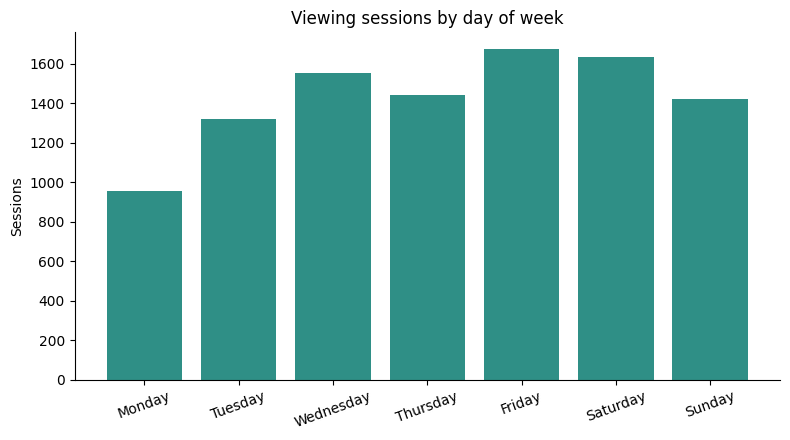

In [0]:
# Viewing by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_views = viewership.groupBy("DayName").count()
day_pd = day_views.toPandas().set_index("DayName").reindex(day_order).reset_index()
display(day_views)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(day_pd["DayName"], day_pd["count"], color=BRAND2)
ax.set_title("Viewing sessions by day of week")
ax.set_ylabel("Sessions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

+-----------------------+
|Average Viewing Seconds|
+-----------------------+
|               548.2803|
+-----------------------+



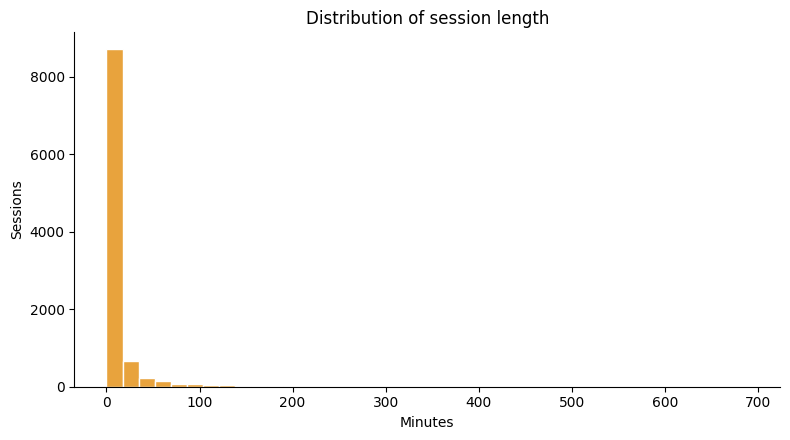

In [0]:
# Average and distribution of viewing duration
from pyspark.sql.functions import avg

viewership.select(avg("DurationSeconds").alias("Average Viewing Seconds")).show()

duration_pd = viewership.select("DurationSeconds").dropna().toPandas()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(duration_pd["DurationSeconds"] / 60, bins=40, color=BRAND, edgecolor="white")
ax.set_title("Distribution of session length")
ax.set_xlabel("Minutes")
ax.set_ylabel("Sessions")
plt.tight_layout()
plt.show()

In [0]:
# Top 10 Channels
top10 = channel_views.limit(10)
display(top10)

Channel2,count
Supersport Live Events,1662
Icc Cricket World Cup 2011,1465
Channel O,1050
Trace Tv,952
Supersport Blitz,896
Africa Magic,859
Cartoon Network,793
Boomerang,714
Cnn,505
E! Entertainment,367


### Summary

- BrightTV has 5,375 registered users and 10,000 viewing sessions in this extract.
- 920 subscribers (~17%) have no gender, age, or province on file — the same records
  are missing all three, pointing to one incomplete-profile segment rather than three
  unrelated data gaps.
- Sport dominates viewing: Supersport Live Events and the ICC Cricket World Cup 2011
  are the two most-watched channels once name casing is normalised.
- Viewing ramps up sharply from 07:00, plateaus through the afternoon and evening, and
  troughs overnight (02:00-05:00).
- Friday and Saturday are the heaviest viewing days; Monday is the lightest.

## 4. Factors Influencing Consumption

What type of factors influence consumption? The original version of this section joined
`viewership` to `users` without first checking for duplicate keys, which fanned out the
join and inflated every count by ~10,000x (e.g. "male" showed as 39,180,000 instead of a
few thousand sessions). The fix below deduplicates both sides on `UserID` before joining
and validates the row count immediately after.

In [0]:
# Fixed join: dedupe both sides on UserID first, then validate the row count
users_dedup = users.dropDuplicates(["UserID"])
viewership_dedup = viewership.dropDuplicates(["UserID", "RecordDate2", "Channel2"])

joined = viewership_dedup.join(users_dedup, on="UserID", how="left")

print("Viewership rows:", viewership_dedup.count())
print("Joined rows:     ", joined.count(), "(should match viewership rows above)")

Viewership rows: 9993
Joined rows:      9993 (should match viewership rows above)


Gender,count
male,8755
female,976
Unknown,262


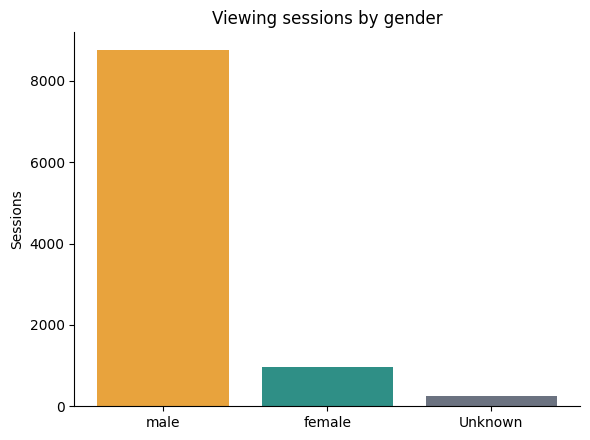

In [0]:
# Gender vs. sessions, on the fixed join
gender_views = joined.na.fill({"Gender": "Unknown"}).groupBy("Gender").count().orderBy("count", ascending=False)
gender_views_pd = gender_views.toPandas()
display(gender_views)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(gender_views_pd["Gender"], gender_views_pd["count"], color=[BRAND, BRAND2, GREY][:len(gender_views_pd)])
ax.set_title("Viewing sessions by gender")
ax.set_ylabel("Sessions")
plt.tight_layout()
plt.show()

Province,AvgDurationSeconds
Free State,645.9520547945206
Eastern Cape,602.0741279069767
Western Cape,585.9864498644987
Kwazulu Natal,568.984015984016
Gauteng,545.7959463160778
Mpumalanga,513.102508178844
Unknown,496.22433460076047
Limpopo,494.4173228346457
North West,455.05523255813955
Northern Cape,432.9826086956522


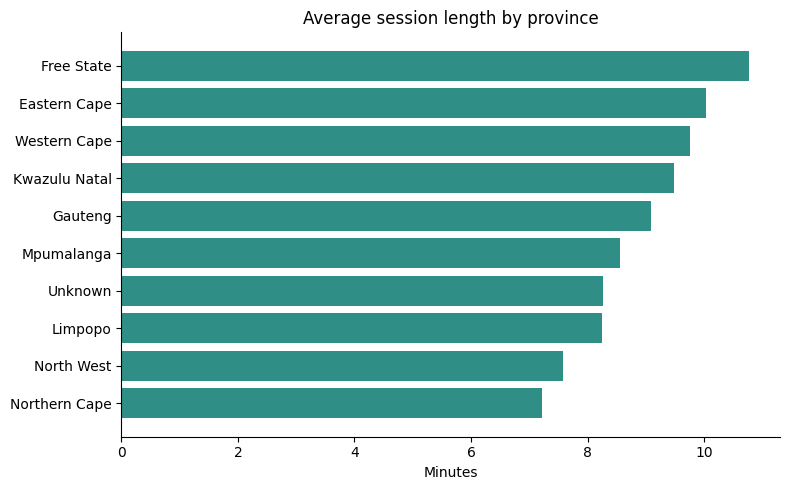

In [0]:
# Average session length by province
province_duration = (
    joined.na.fill({"Province": "Unknown"})
    .groupBy("Province")
    .agg(avg("DurationSeconds").alias("AvgDurationSeconds"))
    .orderBy("AvgDurationSeconds", ascending=False)
)
province_duration_pd = province_duration.toPandas()
display(province_duration)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(province_duration_pd["Province"][::-1], province_duration_pd["AvgDurationSeconds"][::-1] / 60, color=BRAND2)
ax.set_title("Average session length by province")
ax.set_xlabel("Minutes")
plt.tight_layout()
plt.show()

AgeBand,AvgDurationSeconds
18-24,454.2877358490566
25-34,577.137306949807
35-44,552.0622627182992
Unknown,501.78076923076924
55-64,414.22535211267603
0-17,491.06093189964156
45-54,627.854211663067
65+,435.7169811320755


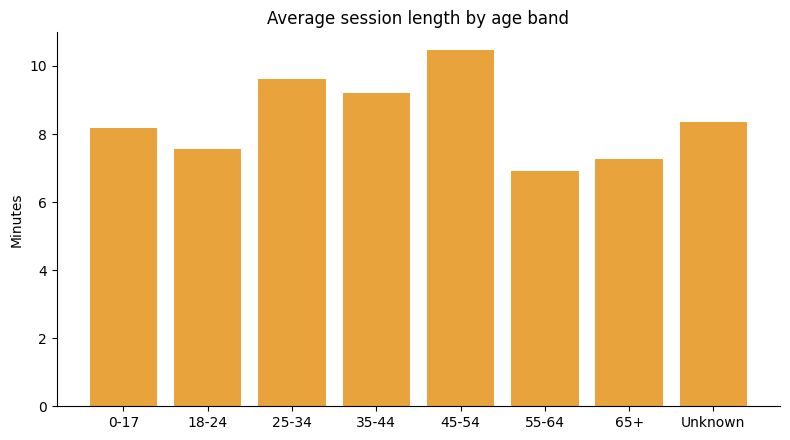

In [0]:
# Average session length by age band
ageband_duration = (
    joined.na.fill({"AgeBand": "Unknown"})
    .groupBy("AgeBand")
    .agg(avg("DurationSeconds").alias("AvgDurationSeconds"))
)
ageband_duration_pd = ageband_duration.toPandas().set_index("AgeBand").reindex(age_band_order + ["Unknown"]).dropna().reset_index()
display(ageband_duration)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ageband_duration_pd["AgeBand"], ageband_duration_pd["AvgDurationSeconds"] / 60, color=BRAND)
ax.set_title("Average session length by age band")
ax.set_ylabel("Minutes")
plt.tight_layout()
plt.show()

## 5. Dashboard: all metrics in one view

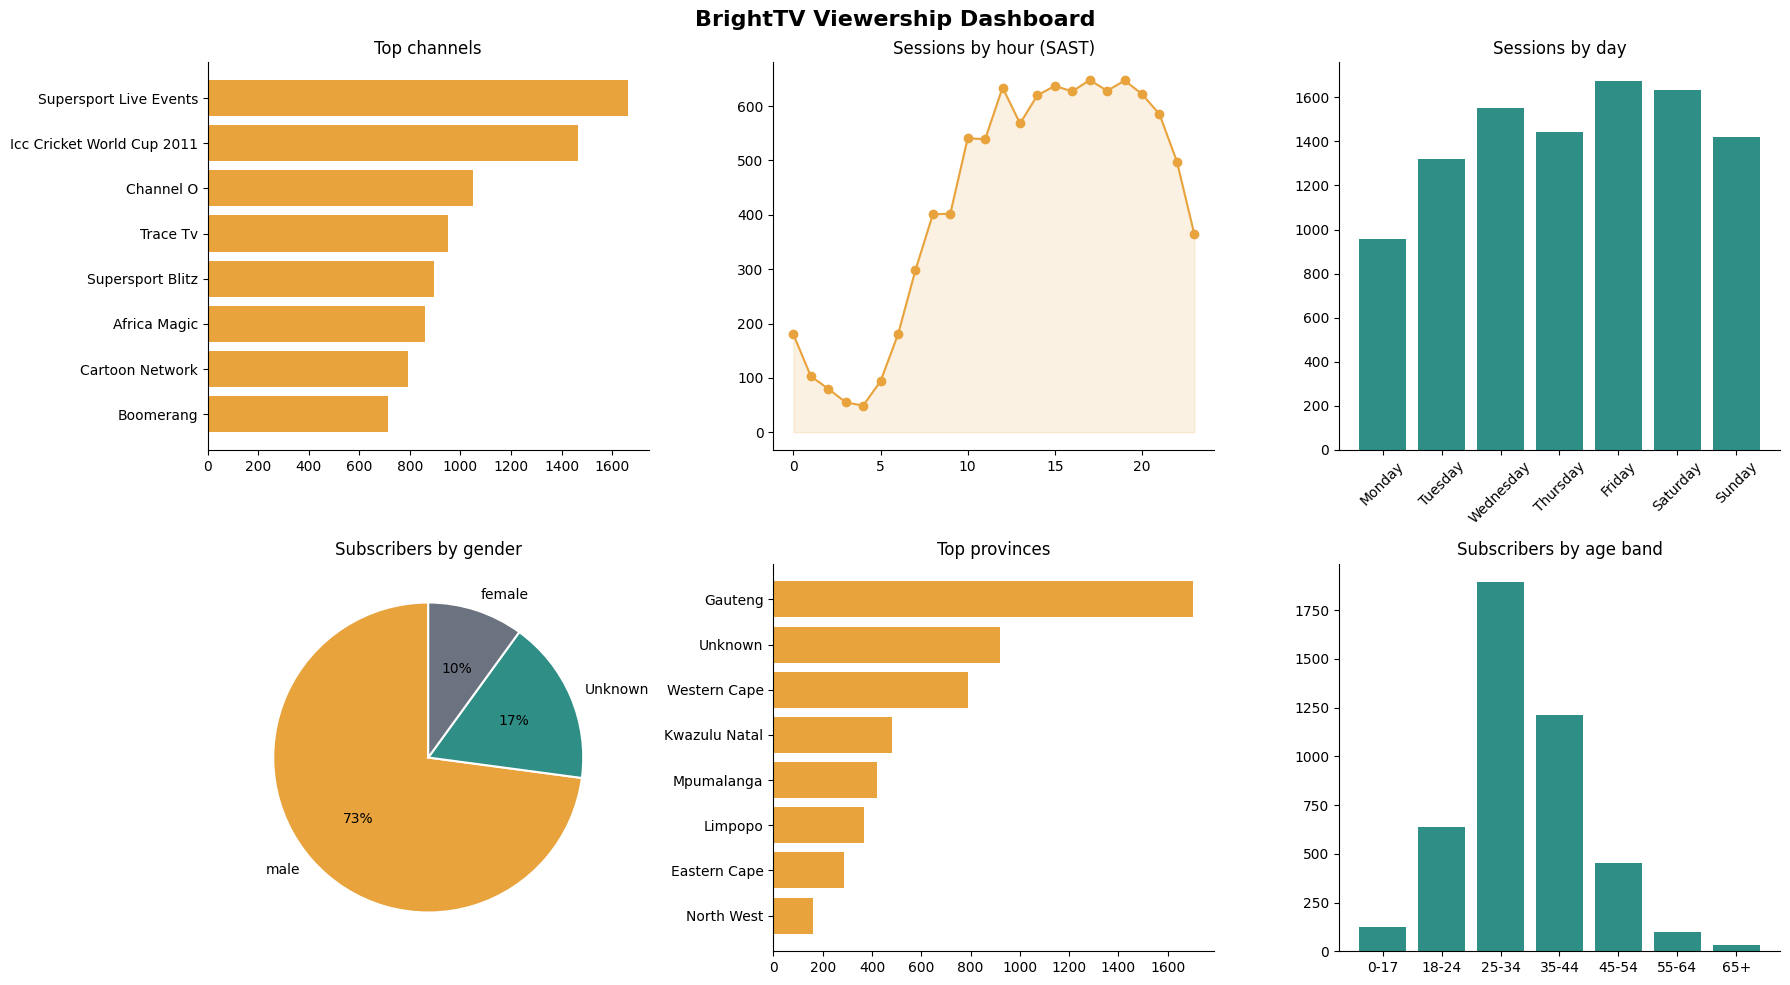

In [0]:
# Combined dashboard figure — saved as PNG for sharing outside Databricks
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top channels
ax = axes[0, 0]
t = channel_pd.head(8).iloc[::-1]
ax.barh(t["Channel2"], t["count"], color=BRAND)
ax.set_title("Top channels")

# Hourly trend
ax = axes[0, 1]
ax.plot(hourly_pd["Hour"], hourly_pd["count"], color=BRAND, marker="o")
ax.fill_between(hourly_pd["Hour"], hourly_pd["count"], color=BRAND, alpha=0.15)
ax.set_title("Sessions by hour (SAST)")

# Day of week
ax = axes[0, 2]
ax.bar(day_pd["DayName"], day_pd["count"], color=BRAND2)
ax.set_title("Sessions by day")
ax.tick_params(axis="x", rotation=45)

# Gender
ax = axes[1, 0]
ax.pie(gender_pd["count"], labels=gender_pd["Gender"], autopct="%1.0f%%",
       colors=[BRAND, BRAND2, GREY][:len(gender_pd)], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Subscribers by gender")

# Province
ax = axes[1, 1]
p = province_pd.head(8).iloc[::-1]
ax.barh(p["Province"], p["count"], color=BRAND)
ax.set_title("Top provinces")

# Age bands
ax = axes[1, 2]
ax.bar(known_ages["AgeBand"], known_ages["count"], color=BRAND2)
ax.set_title("Subscribers by age band")

fig.suptitle("BrightTV Viewership Dashboard", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig("/tmp/brighttv_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

### Key takeaways

- **Fix the join before trusting any "by demographic" number** — the original
  gender-vs-consumption cut was off by a factor of ~10,000 due to a fan-out join.
- **~17% of the subscriber base has an incomplete profile** (no gender, age, or
  province) — worth a data-collection follow-up before demographic splits are used
  for targeting.
- **Sport drives the platform**: Supersport Live Events and the ICC Cricket World
  Cup 2011 lead viewing once channel-name casing is normalised.
- **Evenings and Fridays/Saturdays are peak windows** — useful for scheduling
  promos or new-channel launches.
- **25-34 is the largest known age band**, followed by 35-44 — BrightTV's core
  audience skews toward young adults.